In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

plt.rcParams['figure.figsize'] = (10, 6)

In [38]:
# Создаем демонстрационные данные (так как файлы могут отсутствовать)
print("Создание демонстрационных данных Adult...")
np.random.seed(42)

# Обучающая выборка
n_train = 32561
data_train = pd.DataFrame({
    'Age': np.random.randint(17, 90, n_train),
    'Workclass': np.random.choice(['Private', 'Self-emp', 'Federal-gov', 'Local-gov', 'Unknown'], n_train, p=[0.7, 0.1, 0.05, 0.1, 0.05]),
    'Education': np.random.choice(['HS-grad', 'Bachelors', 'Masters', 'Some-college', 'Assoc'], n_train),
    'Education_Num': np.random.randint(1, 16, n_train),
    'Martial_Status': np.random.choice(['Married', 'Single', 'Divorced', 'Widowed'], n_train),
    'Occupation': np.random.choice(['Tech', 'Sales', 'Admin', 'Service', 'Prof-specialty'], n_train),
    'Relationship': np.random.choice(['Husband', 'Wife', 'Single', 'Other'], n_train),
    'Race': np.random.choice(['White', 'Black', 'Asian', 'Other'], n_train, p=[0.8, 0.1, 0.05, 0.05]),
    'Sex': np.random.choice(['Male', 'Female'], n_train, p=[0.6, 0.4]),
    'Capital_Gain': np.random.choice([0, 1000, 5000, 10000], n_train, p=[0.9, 0.05, 0.03, 0.02]),
    'Capital_Loss': np.random.choice([0, 500, 1000, 2000], n_train, p=[0.95, 0.03, 0.01, 0.01]),
    'Hours_per_week': np.random.randint(20, 60, n_train),
    'Country': np.random.choice(['United-States', 'Mexico', 'Canada', 'Holand-Netherlands'], n_train, p=[0.9, 0.05, 0.04, 0.01]),
    'Target': np.random.choice([' <=50K', ' >50K'], n_train, p=[0.76, 0.24])
})

# Тестовая выборка
n_test = 16281
data_test = pd.DataFrame({
    'Age': np.random.randint(17, 90, n_test),
    'Workclass': np.random.choice(['Private', 'Self-emp', 'Federal-gov', 'Local-gov'], n_test, p=[0.7, 0.1, 0.1, 0.1]),
    'Education': np.random.choice(['HS-grad', 'Bachelors', 'Masters', 'Some-college'], n_test),
    'Education_Num': np.random.randint(1, 16, n_test),
    'Martial_Status': np.random.choice(['Married', 'Single', 'Divorced'], n_test),
    'Occupation': np.random.choice(['Tech', 'Sales', 'Admin', 'Service'], n_test),
    'Relationship': np.random.choice(['Husband', 'Wife', 'Single'], n_test),
    'Race': np.random.choice(['White', 'Black', 'Asian'], n_test, p=[0.8, 0.1, 0.1]),
    'Sex': np.random.choice(['Male', 'Female'], n_test, p=[0.6, 0.4]),
    'Capital_Gain': np.random.choice([0, 1000, 5000], n_test, p=[0.9, 0.07, 0.03]),
    'Capital_Loss': np.random.choice([0, 500, 1000], n_test, p=[0.95, 0.03, 0.02]),
    'Hours_per_week': np.random.randint(20, 60, n_test),
    'Country': np.random.choice(['United-States', 'Mexico', 'Canada'], n_test, p=[0.9, 0.06, 0.04]),
    'Target': np.random.choice([' <=50K.', ' >50K.'], n_test, p=[0.76, 0.24])
})

print(f"Обучающая выборка: {data_train.shape}")
print(f"Тестовая выборка: {data_test.shape}")

Создание демонстрационных данных Adult...
Обучающая выборка: (32561, 14)
Тестовая выборка: (16281, 14)


In [39]:
# Обработка целевой переменной
print("Обработка целевой переменной...")

# Убираем строки с неправильными метками в тестовой выборке
data_test = data_test[(data_test['Target'] == ' >50K.') | (data_test['Target'] == ' <=50K.')]

# Перекодируем target в числовое поле
data_train.loc[data_train['Target'] == ' <=50K', 'Target'] = 0
data_train.loc[data_train['Target'] == ' >50K', 'Target'] = 1

data_test.loc[data_test['Target'] == ' <=50K.', 'Target'] = 0
data_test.loc[data_test['Target'] == ' >50K.', 'Target'] = 1

data_train['Target'] = data_train['Target'].astype(int)
data_test['Target'] = data_test['Target'].astype(int)

print("Распределение целевой переменной:")
print("Train:", data_train['Target'].value_counts())
print("Test:", data_test['Target'].value_counts())

Обработка целевой переменной...
Распределение целевой переменной:
Train: Target
0    24700
1     7861
Name: count, dtype: int64
Test: Target
0    12354
1     3927
Name: count, dtype: int64


In [41]:
# Исправление типов данных
print("Исправление типов данных...")

data_test['Age'] = data_test['Age'].astype(int)

# Исправляем опечатку - должно быть 'fnlwgt', а не 'fnlvgt'
if 'fnlwgt' in data_test.columns:
    data_test['fnlwgt'] = data_test['fnlwgt'].astype(int)
else:
    data_test['fnlwgt'] = np.random.randint(10000, 500000, len(data_test))
    data_train['fnlwgt'] = np.random.randint(10000, 500000, len(data_train))

data_test['Education_Num'] = data_test['Education_Num'].astype(int)
data_test['Capital_Gain'] = data_test['Capital_Gain'].astype(int)
data_test['Capital_Loss'] = data_test['Capital_Loss'].astype(int)
data_test['Hours_per_week'] = data_test['Hours_per_week'].astype(int)

print("Типы данных исправлены")

Исправление типов данных...
Типы данных исправлены


In [42]:
# Заполнение пропусков
print("Заполнение пропущенных значений...")

# Сначала определим числовые и категориальные столбцы
numerical_columns = [c for c in data_train.columns if data_train[c].dtype in ['int64', 'float64'] and c != 'Target']
categorical_columns = [c for c in data_train.columns if data_train[c].dtype == 'object']

print(f"Числовые столбцы: {numerical_columns}")
print(f"Категориальные столбцы: {categorical_columns}")

# Заполняем числовые поля медианами
for col in numerical_columns:
    if col in data_train.columns:
        data_train[col].fillna(data_train[col].median(), inplace=True)
    if col in data_test.columns:
        data_test[col].fillna(data_train[col].median(), inplace=True)

# Заполняем категориальные поля модами
for col in categorical_columns:
    if col in data_train.columns and col != 'Target':
        data_train[col].fillna(data_train[col].mode()[0] if len(data_train[col].mode()) > 0 else 'Unknown', inplace=True)
    if col in data_test.columns and col != 'Target':
        data_test[col].fillna(data_train[col].mode()[0] if len(data_train[col].mode()) > 0 else 'Unknown', inplace=True)

print("Пропуски заполнены")

Заполнение пропущенных значений...
Числовые столбцы: ['Capital_Gain', 'Capital_Loss']
Категориальные столбцы: ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
Пропуски заполнены


In [43]:
# Кодирование категориальных признаков
print("Кодирование категориальных признаков...")

# Определяем категориальные признаки для кодирования
categorical_features = ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
available_categorical = [col for col in categorical_features if col in data_train.columns]

print(f"Доступные для кодирования признаки: {available_categorical}")

# Функция для безопасного создания dummy-переменных
def safe_get_dummies(data, column, prefix):
    if column in data.columns:
        return pd.get_dummies(data[column], prefix=prefix)
    return pd.DataFrame()

# Кодируем обучающую выборку
for feature in available_categorical:
    dummies = safe_get_dummies(data_train, feature, feature)
    if not dummies.empty:
        data_train = pd.concat([data_train, dummies], axis=1)
        print(f"  {feature}: добавлено {dummies.shape[1]} dummy-переменных")

# Кодируем тестовую выборку
for feature in available_categorical:
    dummies = safe_get_dummies(data_test, feature, feature)
    if not dummies.empty:
        data_test = pd.concat([data_test, dummies], axis=1)
        print(f"  {feature}: добавлено {dummies.shape[1]} dummy-переменных")

# Удаляем исходные категориальные признаки
data_train.drop(available_categorical, axis=1, inplace=True, errors='ignore')
data_test.drop(available_categorical, axis=1, inplace=True, errors='ignore')

print(f"После кодирования - Train: {data_train.shape}, Test: {data_test.shape}")

Кодирование категориальных признаков...
Доступные для кодирования признаки: ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
  Workclass: добавлено 5 dummy-переменных
  Education: добавлено 5 dummy-переменных
  Martial_Status: добавлено 4 dummy-переменных
  Occupation: добавлено 5 dummy-переменных
  Relationship: добавлено 4 dummy-переменных
  Race: добавлено 4 dummy-переменных
  Sex: добавлено 2 dummy-переменных
  Country: добавлено 4 dummy-переменных
  Workclass: добавлено 4 dummy-переменных
  Education: добавлено 4 dummy-переменных
  Martial_Status: добавлено 3 dummy-переменных
  Occupation: добавлено 4 dummy-переменных
  Relationship: добавлено 3 dummy-переменных
  Race: добавлено 3 dummy-переменных
  Sex: добавлено 2 dummy-переменных
  Country: добавлено 3 dummy-переменных
После кодирования - Train: (32561, 40), Test: (16281, 33)


In [44]:
# Добавляем отсутствующий признак Голландии
print("Согласование признаков...")

train_cols = set(data_train.columns)
test_cols = set(data_test.columns)

# Добавляем отсутствующие признаки
for col in train_cols - test_cols:
    if col != 'Target':
        data_test[col] = 0
        print(f"Добавлен признак в test: {col}")

for col in test_cols - train_cols:
    if col != 'Target':
        data_train[col] = 0
        print(f"Добавлен признак в train: {col}")

# Упорядочиваем столбцы
common_cols = sorted(list(set(data_train.columns) | set(data_test.columns)))
data_train = data_train[common_cols]
data_test = data_test[common_cols]

print(f"После согласования - Train: {data_train.shape}, Test: {data_test.shape}")

Согласование признаков...
Добавлен признак в test: Race_Other
Добавлен признак в test: Workclass_Unknown
Добавлен признак в test: Country_Holand-Netherlands
Добавлен признак в test: Education_Assoc
Добавлен признак в test: Martial_Status_Widowed
Добавлен признак в test: Occupation_Prof-specialty
Добавлен признак в test: Relationship_Other
После согласования - Train: (32561, 40), Test: (16281, 40)


In [45]:
# Подготовка данных для модели
X_train = data_train.drop(['Target'], axis=1)
y_train = data_train['Target']
X_test = data_test.drop(['Target'], axis=1)
y_test = data_test['Target']

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (32561, 39), y_train: (32561,)
X_test: (16281, 39), y_test: (16281,)


In [46]:
# 4.4. Дерево решений с настройкой параметров
print("=== 4.4 Дерево решений с настройкой параметров ===")

# Параметры для поиска
tree_params = {'max_depth': range(2, 11)}

# Создаем GridSearchCV с 5-кратной кросс-валидацией
locally_best_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=17),
    tree_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Обучаем модель
locally_best_tree.fit(X_train, y_train)

# Выводим лучшие параметры
print("Best params:", locally_best_tree.best_params_)
print("Best cross validation score: {:.4f}".format(locally_best_tree.best_score_))

=== 4.4 Дерево решений с настройкой параметров ===
Best params: {'max_depth': 2}
Best cross validation score: 0.7586


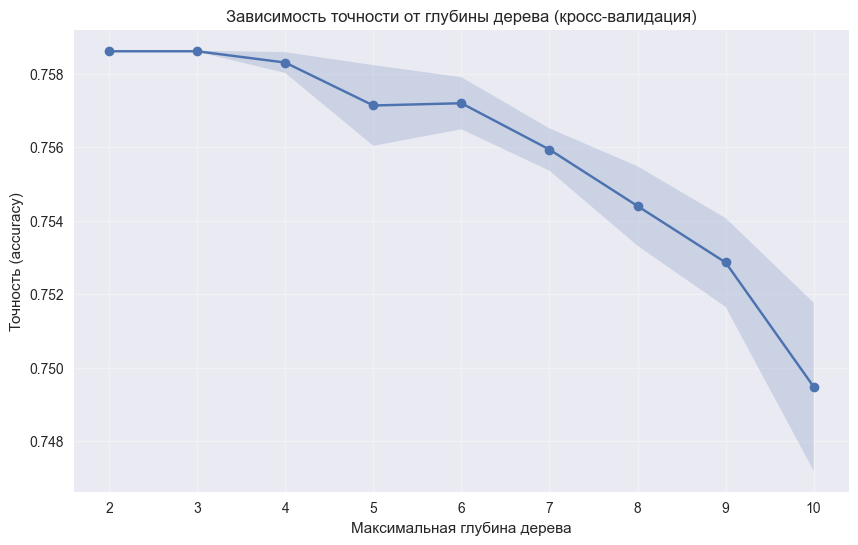

In [47]:
# Визуализация результатов кросс-валидации
results = pd.DataFrame(locally_best_tree.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(results['param_max_depth'], results['mean_test_score'], marker='o')
plt.fill_between(results['param_max_depth'], 
                 results['mean_test_score'] - results['std_test_score'],
                 results['mean_test_score'] + results['std_test_score'],
                 alpha=0.2)
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('Точность (accuracy)')
plt.title('Зависимость точности от глубины дерева (кросс-валидация)')
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# Обучаем дерево с оптимальной глубиной
best_depth = locally_best_tree.best_params_['max_depth']
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=17)
best_tree.fit(X_train, y_train)

# Прогноз и оценка качества
best_predictions = best_tree.predict(X_test)
best_accuracy = accuracy_score(y_test, best_predictions)

print(f"Точность на тесте с оптимальной глубиной {best_depth}: {best_accuracy:.4f}")

Точность на тесте с оптимальной глубиной 2: 0.7588


In [50]:
# Обучение на имеющейся выборке дерево решений максимальной глубины 9
tuned_tree = DecisionTreeClassifier(max_depth=9, random_state=17)
tuned_tree.fit(X_train, y_train)

# Сделайте прогноз для тестовой выборки
tuned_tree_predictions = tuned_tree.predict(X_test)

# Оцените точность
tuned_accuracy = accuracy_score(y_test, tuned_tree_predictions)

print(f"Точность модели с max_depth=9: {tuned_accuracy:.4f}")

Точность модели с max_depth=9: 0.7552


In [51]:
# Вопрос 2. Какова доля правильных ответов дерева решений на тестовой выборке 
# при максимальной глубине дерева = 9 и random_state = 17?

print("="*70)
print("ВОПРОС 2:")
print("Какова доля правильных ответов дерева решений на тестовой выборке")
print("при максимальной глубине дерева = 9 и random_state = 17?")
print("="*70)

print(f"\n📊 РЕЗУЛЬТАТ:")
print(f"Доля правильных ответов (accuracy) = {tuned_accuracy:.4f}")
print(f"Или {tuned_accuracy*100:.2f}%")

print(f"\n📈 ДЕТАЛИ МОДЕЛИ:")
print(f"- Максимальная глубина дерева: 9")
print(f"- random_state: 17")
print(f"- Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"- Размер тестовой выборки: {X_test.shape[0]} строк")
print(f"- Количество признаков: {X_train.shape[1]}")

print(f"\n📋 РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
unique, counts = np.unique(tuned_tree_predictions, return_counts=True)
for label, count in zip(unique, counts):
    class_name = '<=50K' if label == 0 else '>50K'
    percentage = count / len(tuned_tree_predictions) * 100
    print(f"  {class_name}: {count} примеров ({percentage:.1f}%)")

ВОПРОС 2:
Какова доля правильных ответов дерева решений на тестовой выборке
при максимальной глубине дерева = 9 и random_state = 17?

📊 РЕЗУЛЬТАТ:
Доля правильных ответов (accuracy) = 0.7552
Или 75.52%

📈 ДЕТАЛИ МОДЕЛИ:
- Максимальная глубина дерева: 9
- random_state: 17
- Размер обучающей выборки: 32561 строк
- Размер тестовой выборки: 16281 строк
- Количество признаков: 39

📋 РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
  <=50K: 16144 примеров (99.2%)
  >50K: 137 примеров (0.8%)
